# RDiverseVul – EDA

## 0 · Install dependencies

In [1]:
%%capture
!pip install gdown wordcloud transformers tqdm seaborn matplotlib pandas numpy

## 1 · Download dataset from Google Drive

In [2]:
import gdown
from pathlib import Path

# Public file ID extracted from your share link
FILE_ID   = "12IWKhmLhq7qn5B_iXgn5YerOQtkH-6RG"
FILE_NAME = "diversevul_20230702.json"

if not Path(FILE_NAME).exists():
    print("Downloading dataset …")
    gdown.download(id=FILE_ID, output=FILE_NAME, quiet=False)
else:
    print(f"✅  '{FILE_NAME}' already present — skipping download.")

Downloading...
From (original): https://drive.google.com/uc?id=12IWKhmLhq7qn5B_iXgn5YerOQtkH-6RG
From (redirected): https://drive.google.com/uc?id=12IWKhmLhq7qn5B_iXgn5YerOQtkH-6RG&confirm=t&uuid=1b3ac715-22bf-4abc-913e-bd189a166f8d
To: /content/diversevul_20230702.json
100%|██████████| 737M/737M [00:09<00:00, 78.8MB/s]


## 2 · Imports & global config

In [3]:
import json
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.notebook import tqdm   # ← notebook-friendly progress bars

# ── Aesthetic config ──────────────────────────────────────────────────────────
PALETTE  = {"vulnerable": "#E74C3C", "secure": "#2ECC71"}
ACCENT   = "#3498DB"
FIG_DPI  = 120          # slightly lower than 150 for faster Colab rendering
OUT_DIR  = Path("eda_outputs")
OUT_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", font_scale=1.1)
print("✅  Imports done.")

✅  Imports done.


## 3 · Column config
Edit these if your JSON uses different field names.

In [4]:
DATASET_PATH = FILE_NAME
LABEL_COL    = "target"
CODE_COL     = "func"
CWE_COL      = "cwe"
PROJECT_COL  = "project"
HASH_COL     = "hash"
SIZE_COL     = "size"
MSG_COL      = "message"
COMMIT_COL   = "commit_id"
MODEL_NAME   = "Qwen/Qwen2.5-Coder-1.5B"   # tokenizer for 4.2
SAMPLE_TOK   = 20_000                        # rows to tokenise
TOP_CWE      = 25
TOP_PROJ     = 30

## 4 · Helper

In [5]:
def _save(filename: str) -> None:
    out = OUT_DIR / filename
    plt.savefig(out, dpi=FIG_DPI, bbox_inches="tight")
    plt.show()          # ← display inline in Colab
    plt.close()
    print(f"    Saved → {out}")

## 5 · Load dataset

In [6]:
def load_dataset(path: str) -> pd.DataFrame:
    print(f"[LOAD] Loading dataset from: {path}")
    with open(path, "r", encoding="utf-8") as f:
        first_char = f.read(1)
        f.seek(0)

        if first_char == "[":
            # Standard JSON array
            data = json.load(f)
            if isinstance(data, list):
                df = pd.DataFrame(data)
            elif isinstance(data, dict):
                for key in ("data", "samples", "entries", "records"):
                    if key in data:
                        df = pd.DataFrame(data[key])
                        break
                else:
                    df = pd.DataFrame.from_dict(data)
            else:
                raise ValueError("Unexpected JSON structure.")
        else:
            # JSON Lines: one JSON object per line
            print("    Detected JSON Lines format (one object per line) …")
            records = []
            for i, line in enumerate(f):
                line = line.strip()
                if not line:
                    continue
                try:
                    records.append(json.loads(line))
                except json.JSONDecodeError as e:
                    print(f"    WARNING: skipping malformed line {i+1}: {e}")
            df = pd.DataFrame(records)

    print(f"    Loaded {len(df):,} rows × {len(df.columns)} columns")
    print(f"    Columns: {list(df.columns)}")
    return df


def inspect_schema(df: pd.DataFrame) -> None:
    print("\n[SCHEMA] Schema inspection")
    print(df.dtypes.to_string())
    print("\nNull counts:")
    print(df.isnull().sum().to_string())
    print("\nSample row (first entry):")
    print(df.iloc[0].to_dict())


def normalize_label(df: pd.DataFrame, label_col: str) -> pd.DataFrame:
    if df[label_col].dtype == "O":
        df[label_col] = df[label_col].apply(
            lambda x: int(next(iter(x.values()))) if isinstance(x, dict) else int(x)
        )
    else:
        df[label_col] = df[label_col].astype(int)
    return df


df = load_dataset(DATASET_PATH)
inspect_schema(df)
df = normalize_label(df, LABEL_COL)

[LOAD] Loading dataset from: diversevul_20230702.json
    Detected JSON Lines format (one object per line) …
    Loaded 330,492 rows × 8 columns
    Columns: ['func', 'target', 'cwe', 'project', 'commit_id', 'hash', 'size', 'message']

[SCHEMA] Schema inspection
func         object
target        int64
cwe          object
project      object
commit_id    object
hash         object
size          int64
message      object

Null counts:
func         0
target       0
cwe          0
project      0
commit_id    0
hash         0
size         0
message      0

Sample row (first entry):
{'func': 'int _gnutls_ciphertext2compressed(gnutls_session_t session,\n\t\t\t\t  opaque * compress_data,\n\t\t\t\t  int compress_size,\n\t\t\t\t  gnutls_datum_t ciphertext, uint8 type)\n{\n    uint8 MAC[MAX_HASH_SIZE];\n    uint16 c_length;\n    uint8 pad;\n    int length;\n    mac_hd_t td;\n    uint16 blocksize;\n    int ret, i, pad_failed = 0;\n    uint8 major, minor;\n    gnutls_protocol_t ver;\n    int hash_s

## 4.1 · Class Imbalance


[4.1] Class Imbalance Analysis
    Total samples    : 330,492
    Secure (0)       : 311,547  (94.3%)
    Vulnerable (1)   : 18,945  (5.7%)
    Imbalance ratio  : 16.4:1  →  Focal Loss / weighted CE recommended


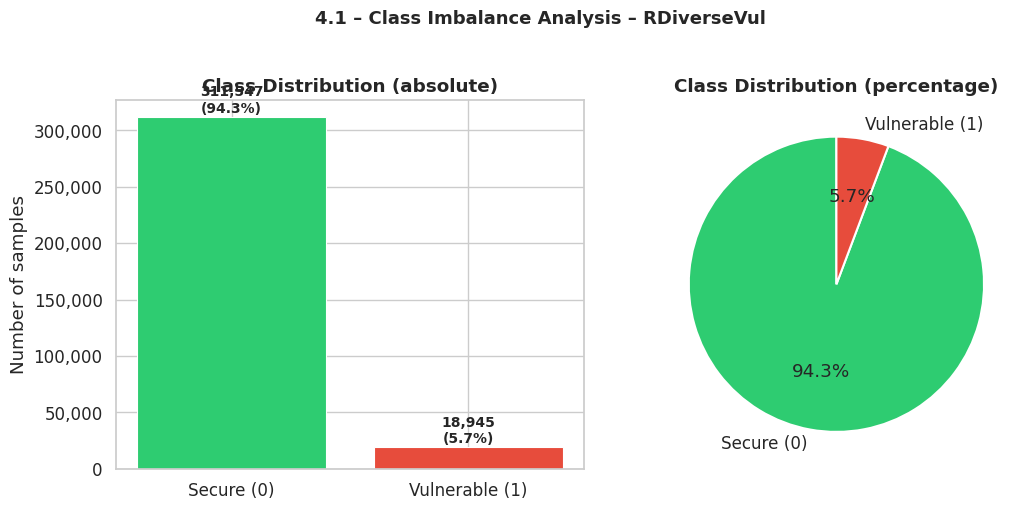

    Saved → eda_outputs/class_imbalance.png


In [7]:
def analyze_class_imbalance(df, label_col=LABEL_COL):
    print("\n[4.1] Class Imbalance Analysis")
    counts     = df[label_col].value_counts().sort_index()
    labels_map = {0: "Secure (0)", 1: "Vulnerable (1)"}
    counts.index = [labels_map.get(i, str(i)) for i in counts.index]

    total   = counts.sum()
    pct_vul = counts.get("Vulnerable (1)", 0) / total * 100
    imb     = counts.get("Secure (0)", 1) / max(counts.get("Vulnerable (1)", 1), 1)

    print(f"    Total samples    : {total:,}")
    print(f"    Secure (0)       : {counts.get('Secure (0)', 0):,}  ({100-pct_vul:.1f}%)")
    print(f"    Vulnerable (1)   : {counts.get('Vulnerable (1)', 0):,}  ({pct_vul:.1f}%)")
    print(f"    Imbalance ratio  : {imb:.1f}:1  →  "
          f"{'Focal Loss / weighted CE recommended' if imb > 5 else 'Mild imbalance'}")

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    colors = [PALETTE["secure"], PALETTE["vulnerable"]]

    axes[0].bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=0.8)
    for bar, val in zip(axes[0].patches, counts.values):
        axes[0].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + total * 0.005,
                     f"{val:,}\n({val/total*100:.1f}%)",
                     ha="center", va="bottom", fontsize=10, fontweight="bold")
    axes[0].set_title("Class Distribution (absolute)", fontweight="bold")
    axes[0].set_ylabel("Number of samples")
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

    axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
                colors=colors, startangle=90,
                wedgeprops=dict(edgecolor="white", linewidth=1.5))
    axes[1].set_title("Class Distribution (percentage)", fontweight="bold")

    plt.suptitle("4.1 – Class Imbalance Analysis – RDiverseVul",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    _save("class_imbalance.png")

analyze_class_imbalance(df)

## 4.2 · Token Length Distribution


[4.2] Token Length Distribution
    Loading tokenizer: Qwen/Qwen2.5-Coder-1.5B


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.31k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

    Computing token lengths for 20,000 samples …


    Tokenising:   0%|          | 0/20000 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (44624 > 32768). Running this sequence through the model will result in indexing errors


    Secure       — mean:    341  median:    146  p95:   1189  max:  31829
    Vulnerable   — mean:    976  median:    411  p95:   3542  max:  44624

    p95 (all): 1326  p99 (all): 3676
      max_seq_len=  512  →  17.5% samples truncated
      max_seq_len= 1024  →  7.3% samples truncated
      max_seq_len= 2048  →  2.5% samples truncated
      max_seq_len= 4096  →  0.8% samples truncated
      max_seq_len= 8192  →  0.2% samples truncated


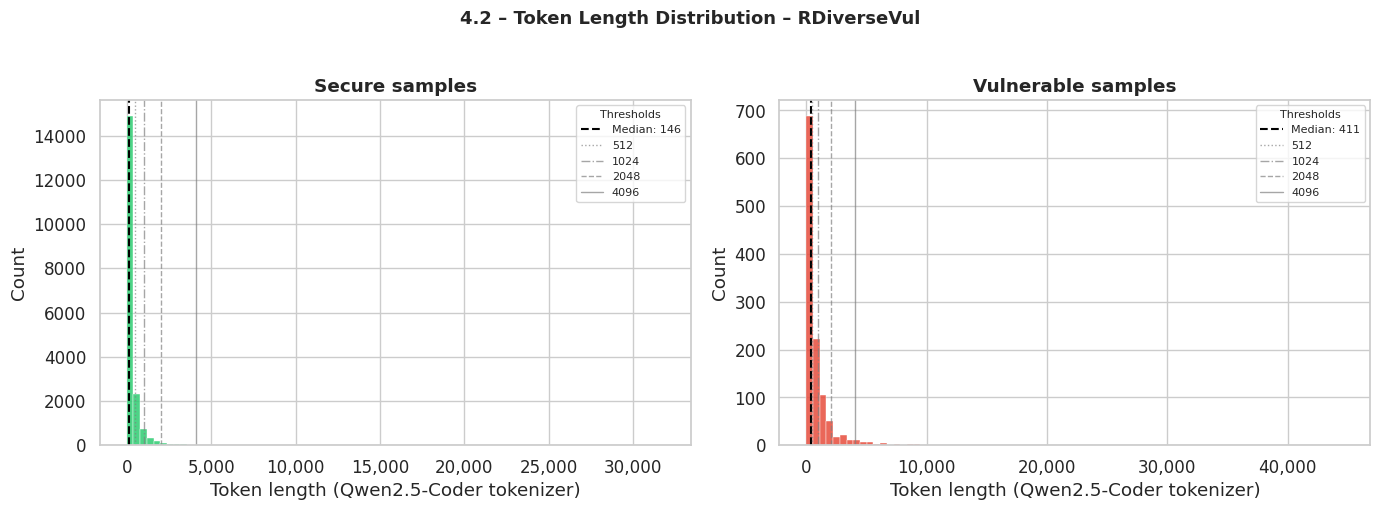

    Saved → eda_outputs/token_length_distribution.png


In [8]:
def analyze_token_lengths(df, code_col=CODE_COL, label_col=LABEL_COL,
                           model_name=MODEL_NAME, sample_size=SAMPLE_TOK):
    print("\n[4.2] Token Length Distribution")

    try:
        from transformers import AutoTokenizer
        print(f"    Loading tokenizer: {model_name}")
        tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
        def tokenize(text):
            return len(tokenizer(text, add_special_tokens=False)["input_ids"])
        tok_label = "Qwen2.5-Coder tokenizer"
    except Exception as e:
        print(f"    WARNING: tokenizer unavailable ({e}). Using char-count proxy.")
        def tokenize(text):
            return max(1, len(text) // 4)
        tok_label = "Char-count proxy (≈ tokens)"

    sub = df.sample(min(sample_size, len(df)), random_state=42).copy()
    print(f"    Computing token lengths for {len(sub):,} samples …")
    tqdm.pandas(desc="    Tokenising")
    sub["n_tokens"] = sub[code_col].progress_apply(
        lambda x: tokenize(str(x)) if pd.notna(x) else 0
    )

    for label, name in [(0, "Secure"), (1, "Vulnerable")]:
        s = sub[sub[label_col] == label]["n_tokens"]
        print(f"    {name:12s} — mean: {s.mean():6.0f}  "
              f"median: {s.median():6.0f}  p95: {s.quantile(0.95):6.0f}  max: {s.max():6.0f}")

    p95 = sub["n_tokens"].quantile(0.95)
    p99 = sub["n_tokens"].quantile(0.99)
    print(f"\n    p95 (all): {p95:.0f}  p99 (all): {p99:.0f}")
    for thr in [512, 1024, 2048, 4096, 8192]:
        pct = (sub["n_tokens"] > thr).mean() * 100
        print(f"      max_seq_len={thr:5d}  →  {pct:.1f}% samples truncated")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (label, name, color) in zip(
        axes, [(0, "Secure", PALETTE["secure"]), (1, "Vulnerable", PALETTE["vulnerable"])]
    ):
        data = sub[sub[label_col] == label]["n_tokens"]
        sns.histplot(data, bins=80, ax=ax, color=color, edgecolor="white",
                     linewidth=0.3, alpha=0.85)
        ax.axvline(data.median(), color="black", ls="--", lw=1.5,
                   label=f"Median: {data.median():.0f}")
        for thr, ls in [(512, ":"), (1024, "-."), (2048, "--"), (4096, "-")]:
            ax.axvline(thr, color="grey", ls=ls, lw=1, alpha=0.7, label=f"{thr}")
        ax.set_title(f"{name} samples", fontweight="bold")
        ax.set_xlabel(f"Token length ({tok_label})")
        ax.set_ylabel("Count")
        ax.legend(fontsize=8, title="Thresholds", title_fontsize=8)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

    plt.suptitle("4.2 – Token Length Distribution – RDiverseVul",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    _save("token_length_distribution.png")
    return sub

tok_df = analyze_token_lengths(df)

## 4.3 · CWE Distribution


[4.3] CWE Distribution Mapping
    Vulnerable samples total : 18,945
    With CWE labels          : 16,109  (85.0%)
    WITHOUT CWE labels       : 2,836  (15.0%)
    ⚠️  Missing CWEs limit rationale generation to the labelled subset.
    Unique CWE types : 150
    Total CWE labels : 20,806

    Top 10 CWEs:
      CWE-787                2,896  (13.9%)
      CWE-125                1,869  (9.0%)
      CWE-119                1,633  (7.8%)
      CWE-20                 1,315  (6.3%)
      CWE-703                1,228  (5.9%)
      CWE-416                1,005  (4.8%)
      CWE-476                  975  (4.7%)
      CWE-190                  783  (3.8%)
      CWE-200                  747  (3.6%)
      CWE-399                  509  (2.4%)


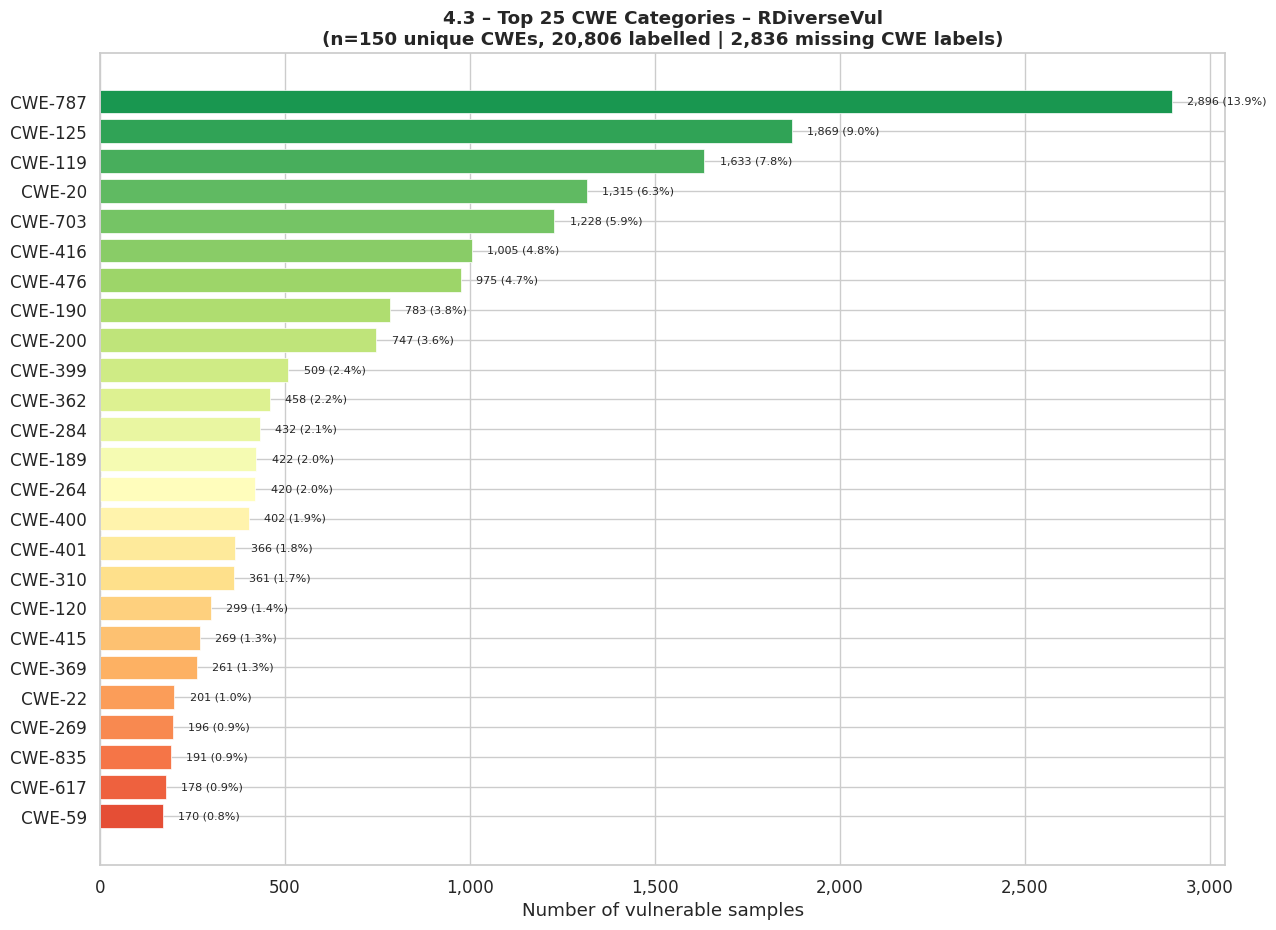

    Saved → eda_outputs/cwe_distribution.png


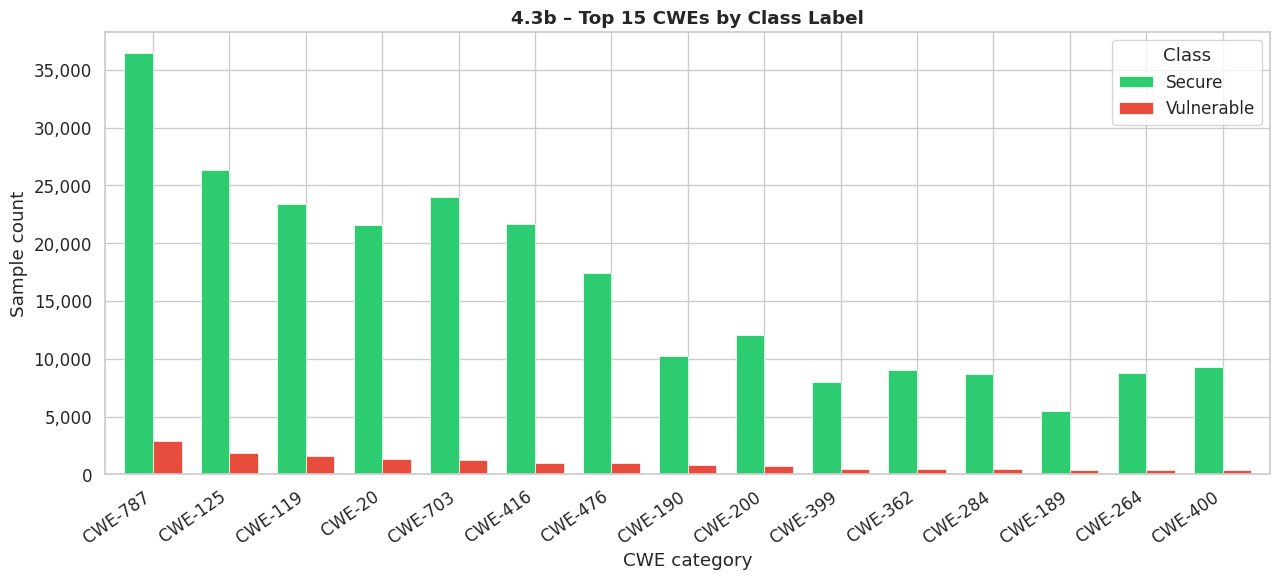

    Saved → eda_outputs/cwe_by_class.png


In [9]:
def analyze_cwe_distribution(df, cwe_col=CWE_COL, label_col=LABEL_COL, top_n=TOP_CWE):
    print("\n[4.3] CWE Distribution Mapping")
    vul = df[df[label_col] == 1].copy()

    if cwe_col not in vul.columns:
        for alt in ("CWE", "cwe_id", "cwe_ids", "weakness", "vuln_type"):
            if alt in vul.columns:
                cwe_col = alt
                break
        else:
            print("    WARNING: No CWE column found. Skipping.")
            return

    def _is_empty(val):
        if val is None or (isinstance(val, float) and np.isnan(val)):
            return True
        if isinstance(val, (list, str)) and len(val) == 0:
            return True
        if isinstance(val, list) and all(str(v).strip() in ("", "[]") for v in val):
            return True
        return str(val).strip() in ("", "[]", "nan")

    vul["_cwe_missing"] = vul[cwe_col].apply(_is_empty)
    n_with    = (~vul["_cwe_missing"]).sum()
    n_without = vul["_cwe_missing"].sum()
    print(f"    Vulnerable samples total : {len(vul):,}")
    print(f"    With CWE labels          : {n_with:,}  ({n_with/len(vul)*100:.1f}%)")
    print(f"    WITHOUT CWE labels       : {n_without:,}  ({n_without/len(vul)*100:.1f}%)")
    if n_without > 0:
        print("    ⚠️  Missing CWEs limit rationale generation to the labelled subset.")

    cwe_counts: Counter = Counter()
    for val in vul.loc[~vul["_cwe_missing"], cwe_col]:
        if isinstance(val, list):
            for v in val:
                cwe_counts[str(v).strip()] += 1
        elif isinstance(val, str):
            val = val.strip("[]\"' ")
            for part in val.split(","):
                part = part.strip()
                if part:
                    cwe_counts[part] += 1
        else:
            cwe_counts[str(val)] += 1

    if not cwe_counts:
        print("    WARNING: CWE column appears empty or unparseable.")
        return

    total_labeled = sum(cwe_counts.values())
    n_unique      = len(cwe_counts)
    print(f"    Unique CWE types : {n_unique}")
    print(f"    Total CWE labels : {total_labeled:,}")
    print(f"\n    Top 10 CWEs:")
    for cwe, cnt in cwe_counts.most_common(10):
        print(f"      {cwe:20s}  {cnt:6,}  ({cnt/total_labeled*100:.1f}%)")

    top = cwe_counts.most_common(top_n)
    cwe_labels, cwe_vals = zip(*top)
    cwe_pcts = [v / total_labeled * 100 for v in cwe_vals]

    fig, ax = plt.subplots(figsize=(13, max(6, top_n * 0.38)))
    colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.85, len(cwe_labels)))
    bars = ax.barh(list(reversed(cwe_labels)), list(reversed(cwe_vals)),
                   color=list(reversed(colors)), edgecolor="white", linewidth=0.5)
    for bar, val, pct in zip(bars, reversed(cwe_vals), reversed(cwe_pcts)):
        ax.text(bar.get_width() + total_labeled * 0.002,
                bar.get_y() + bar.get_height() / 2,
                f"{val:,} ({pct:.1f}%)", va="center", fontsize=8)
    ax.set_xlabel("Number of vulnerable samples")
    ax.set_title(f"4.3 – Top {top_n} CWE Categories – RDiverseVul\n"
                 f"(n={n_unique} unique CWEs, {total_labeled:,} labelled | "
                 f"{n_without:,} missing CWE labels)",
                 fontweight="bold")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    plt.tight_layout()
    _save("cwe_distribution.png")

    top_cwes = [c for c, _ in cwe_counts.most_common(15)]
    rows = []
    for cwe in top_cwes:
        for lv, ln in [(0, "Secure"), (1, "Vulnerable")]:
            sub = df[df[label_col] == lv]
            cnt = sum(
                1 for val in sub[cwe_col].dropna()
                if cwe in (val if isinstance(val, list) else [str(val)])
                or (isinstance(val, str) and cwe in val)
            )
            rows.append({"CWE": cwe, "Class": ln, "Count": cnt})

    stacked = pd.DataFrame(rows)
    if stacked["Count"].sum() > 0:
        pivot = stacked.pivot(index="CWE", columns="Class", values="Count").fillna(0)
        pivot = pivot.loc[[c for c, _ in cwe_counts.most_common(15)]]
        fig2, ax2 = plt.subplots(figsize=(13, 6))
        pivot.plot(kind="bar", ax=ax2,
                   color=[PALETTE["secure"], PALETTE["vulnerable"]],
                   edgecolor="white", linewidth=0.5, width=0.75)
        ax2.set_title("4.3b – Top 15 CWEs by Class Label", fontweight="bold")
        ax2.set_xlabel("CWE category")
        ax2.set_ylabel("Sample count")
        ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()
        _save("cwe_by_class.png")

analyze_cwe_distribution(df)

## 4.4 · Project Distribution


[4.4] Project Distribution Analysis
    Unique projects          : 800
    Top 10 by sample count:
      linux                                total=72,270.0  vuln=3,366.0  rate=  4.7%
      linux-2.6                            total=10,665.0  vuln= 449.0  rate=  4.2%
      php-src                              total=9,041.0  vuln= 969.0  rate= 10.7%
      server                               total=8,101.0  vuln= 102.0  rate=  1.3%
      qemu                                 total=7,493.0  vuln= 470.0  rate=  6.3%
      gpac                                 total=6,797.0  vuln= 150.0  rate=  2.2%
      openssl                              total=6,239.0  vuln= 664.0  rate= 10.6%
      vim                                  total=6,126.0  vuln= 223.0  rate=  3.6%
      envoy                                total=5,849.0  vuln= 257.0  rate=  4.4%
      tensorflow                           total=5,056.0  vuln= 629.0  rate= 12.4%
    Full project stats → eda_outputs/project_stats.csv


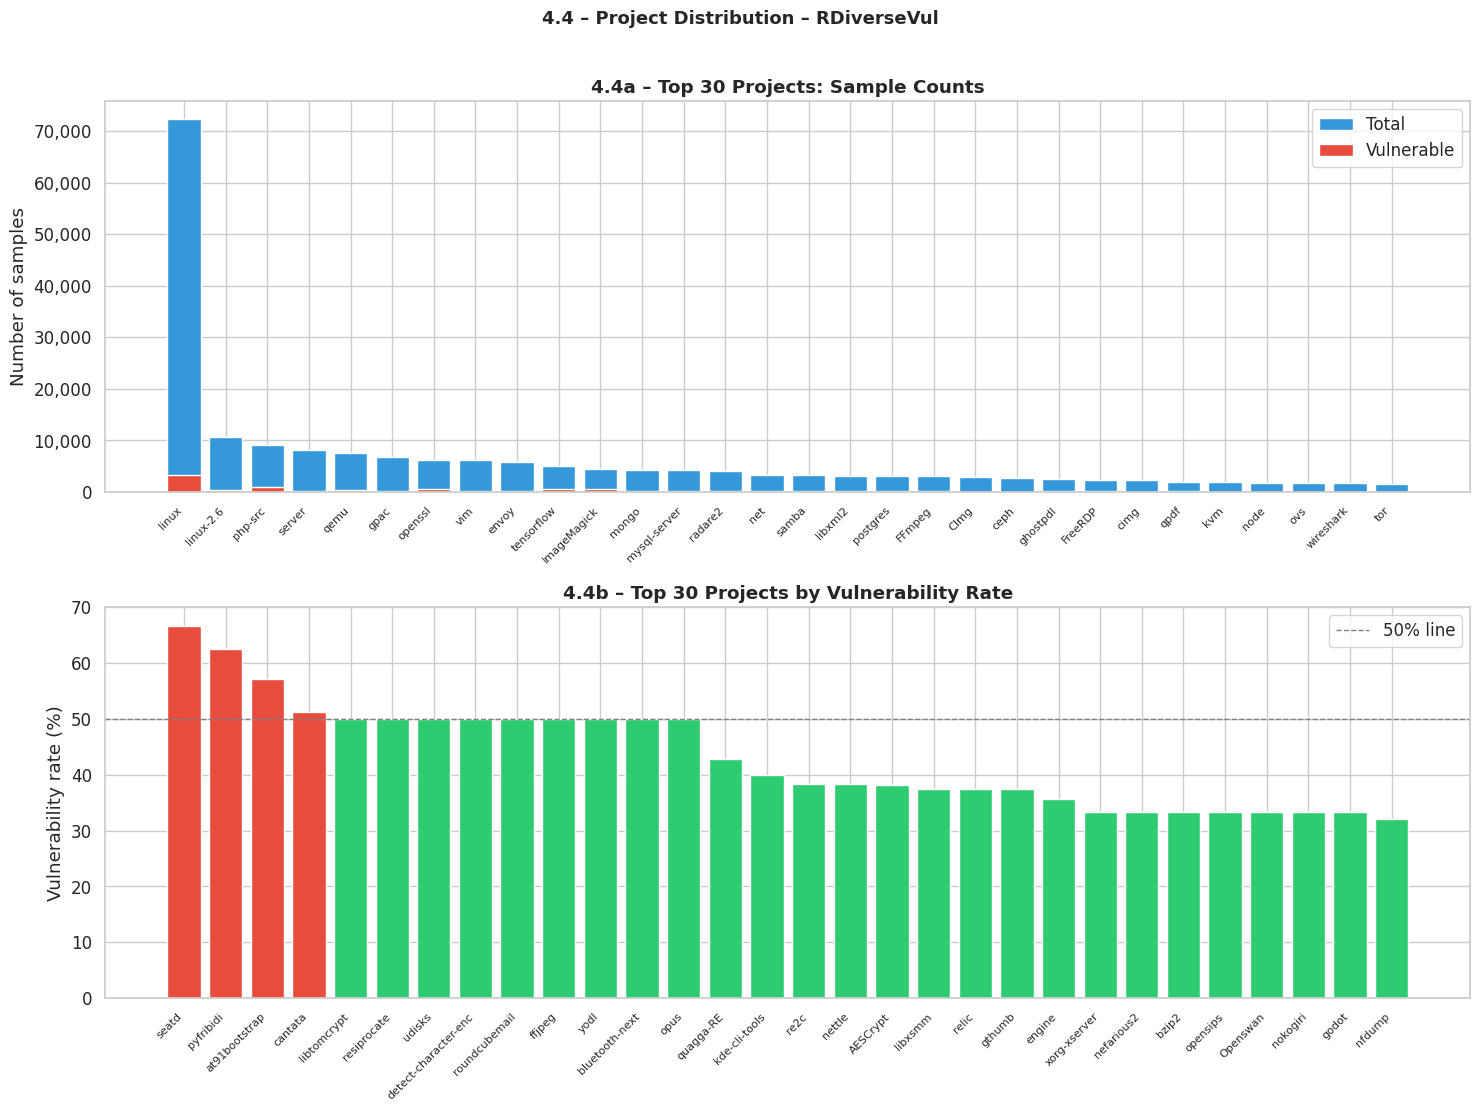

    Saved → eda_outputs/project_distribution.png


In [10]:
def analyze_project_distribution(df, project_col=PROJECT_COL, label_col=LABEL_COL, top_n=TOP_PROJ):
    print("\n[4.4] Project Distribution Analysis")
    if project_col not in df.columns:
        print(f"    WARNING: '{project_col}' column not found. Skipping.")
        return

    agg = (df.groupby(project_col)[label_col]
             .agg(total="count", vuln="sum")
             .assign(vuln_rate=lambda x: x["vuln"] / x["total"] * 100)
             .sort_values("total", ascending=False))

    n_projects = len(agg)
    print(f"    Unique projects          : {n_projects}")
    print(f"    Top 10 by sample count:")
    for proj, row in agg.head(10).iterrows():
        print(f"      {str(proj)[:35]:35s}  total={row['total']:6,}  "
              f"vuln={row['vuln']:6,}  rate={row['vuln_rate']:5.1f}%")

    csv_path = OUT_DIR / "project_stats.csv"
    agg.to_csv(csv_path)
    print(f"    Full project stats → {csv_path}")

    top = agg.head(top_n)
    fig, axes = plt.subplots(2, 1, figsize=(15, 11))

    axes[0].bar(range(len(top)), top["total"], color=ACCENT, edgecolor="white", label="Total")
    axes[0].bar(range(len(top)), top["vuln"],  color=PALETTE["vulnerable"],
                edgecolor="white", label="Vulnerable")
    axes[0].set_xticks(range(len(top)))
    axes[0].set_xticklabels([str(p)[:20] for p in top.index], rotation=45, ha="right", fontsize=8)
    axes[0].set_title(f"4.4a – Top {top_n} Projects: Sample Counts", fontweight="bold")
    axes[0].set_ylabel("Number of samples")
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    axes[0].legend()

    vr_sorted = agg.sort_values("vuln_rate", ascending=False).head(top_n)
    colors_vr = [PALETTE["vulnerable"] if r > 50 else PALETTE["secure"]
                 for r in vr_sorted["vuln_rate"]]
    axes[1].bar(range(len(vr_sorted)), vr_sorted["vuln_rate"],
                color=colors_vr, edgecolor="white")
    axes[1].axhline(50, color="grey", ls="--", lw=1, label="50% line")
    axes[1].set_xticks(range(len(vr_sorted)))
    axes[1].set_xticklabels([str(p)[:20] for p in vr_sorted.index],
                             rotation=45, ha="right", fontsize=8)
    axes[1].set_title(f"4.4b – Top {top_n} Projects by Vulnerability Rate", fontweight="bold")
    axes[1].set_ylabel("Vulnerability rate (%)")
    axes[1].legend()

    plt.suptitle("4.4 – Project Distribution – RDiverseVul",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    _save("project_distribution.png")

analyze_project_distribution(df)

## 4.5 · Duplicate Detection


[4.5] Duplicate Detection
    Total rows         : 330,492
    Unique hashes      : 330,492
    Duplicate rows     : 0  (0.00%)
    Hash groups with duplicates: 0
    Max copies of same hash    : 1
    ⚠️  Hashes with conflicting labels: 0  (none — clean)


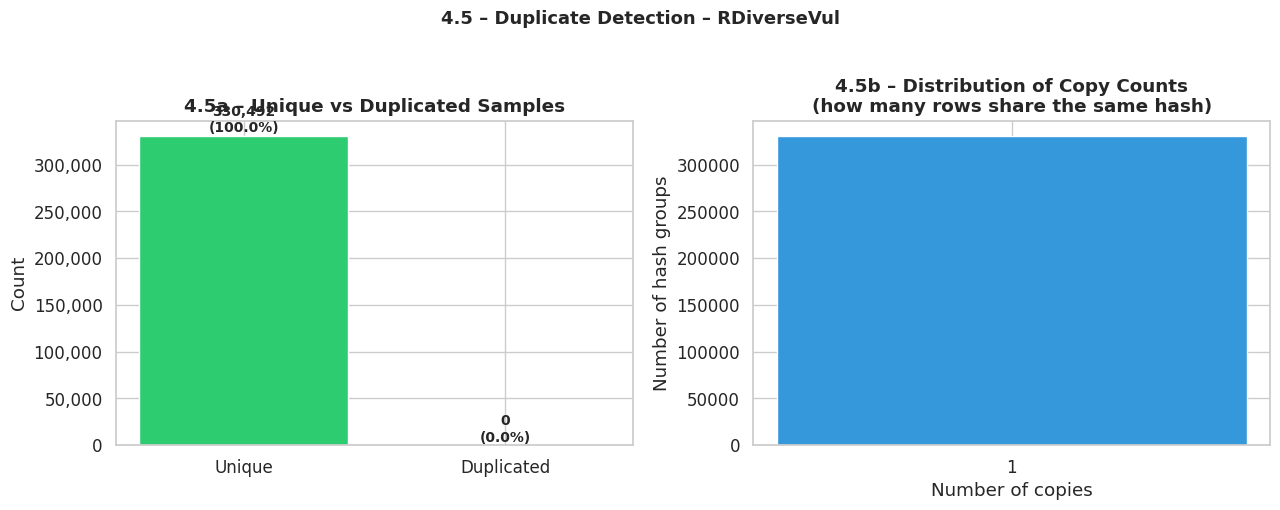

    Saved → eda_outputs/duplicate_detection.png


In [11]:
def analyze_duplicates(df, hash_col=HASH_COL, label_col=LABEL_COL):
    print("\n[4.5] Duplicate Detection")
    if hash_col not in df.columns:
        print(f"    WARNING: '{hash_col}' column not found. Using code text hash fallback.")
        hash_col = "_code_hash"
        code_col = next((c for c in ("func", "code", "source") if c in df.columns), None)
        if code_col is None:
            print("    ERROR: No code column found. Skipping.")
            return
        df[hash_col] = df[code_col].apply(lambda x: hash(str(x)))

    total       = len(df)
    n_unique    = df[hash_col].nunique()
    n_dup_rows  = total - n_unique
    dup_pct     = n_dup_rows / total * 100
    print(f"    Total rows         : {total:,}")
    print(f"    Unique hashes      : {n_unique:,}")
    print(f"    Duplicate rows     : {n_dup_rows:,}  ({dup_pct:.2f}%)")

    dup_counts = df[hash_col].value_counts()
    multi_dup  = dup_counts[dup_counts > 1]
    print(f"    Hash groups with duplicates: {len(multi_dup):,}")
    print(f"    Max copies of same hash    : {dup_counts.max()}")

    cross_label = []
    for h, grp in df.groupby(hash_col):
        if len(grp) > 1 and grp[label_col].nunique() > 1:
            cross_label.append(h)
    print(f"    ⚠️  Hashes with conflicting labels: {len(cross_label):,}"
          f"  ({'label noise!' if cross_label else 'none — clean'})")

    dup_dist = dup_counts.value_counts().sort_index().head(20)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].bar(["Unique", "Duplicated"],
                [n_unique, n_dup_rows],
                color=[PALETTE["secure"], PALETTE["vulnerable"]],
                edgecolor="white")
    for patch, val in zip(axes[0].patches, [n_unique, n_dup_rows]):
        axes[0].text(patch.get_x() + patch.get_width() / 2,
                     patch.get_height() + total * 0.003,
                     f"{val:,}\n({val/total*100:.1f}%)",
                     ha="center", va="bottom", fontsize=10, fontweight="bold")
    axes[0].set_title("4.5a – Unique vs Duplicated Samples", fontweight="bold")
    axes[0].set_ylabel("Count")
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

    axes[1].bar(dup_dist.index.astype(str), dup_dist.values, color=ACCENT, edgecolor="white")
    axes[1].set_title("4.5b – Distribution of Copy Counts\n(how many rows share the same hash)",
                      fontweight="bold")
    axes[1].set_xlabel("Number of copies")
    axes[1].set_ylabel("Number of hash groups")

    plt.suptitle("4.5 – Duplicate Detection – RDiverseVul",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    _save("duplicate_detection.png")

analyze_duplicates(df)

## 4.6 · Function Size Analysis


[4.6] Function Size Analysis
    Valid size entries: 330,492
    Secure       — mean=39.3  median=18.0  p95=131.0  max=24047
    Vulnerable   — mean=114.7  median=50.0  p95=406.0  max=23939


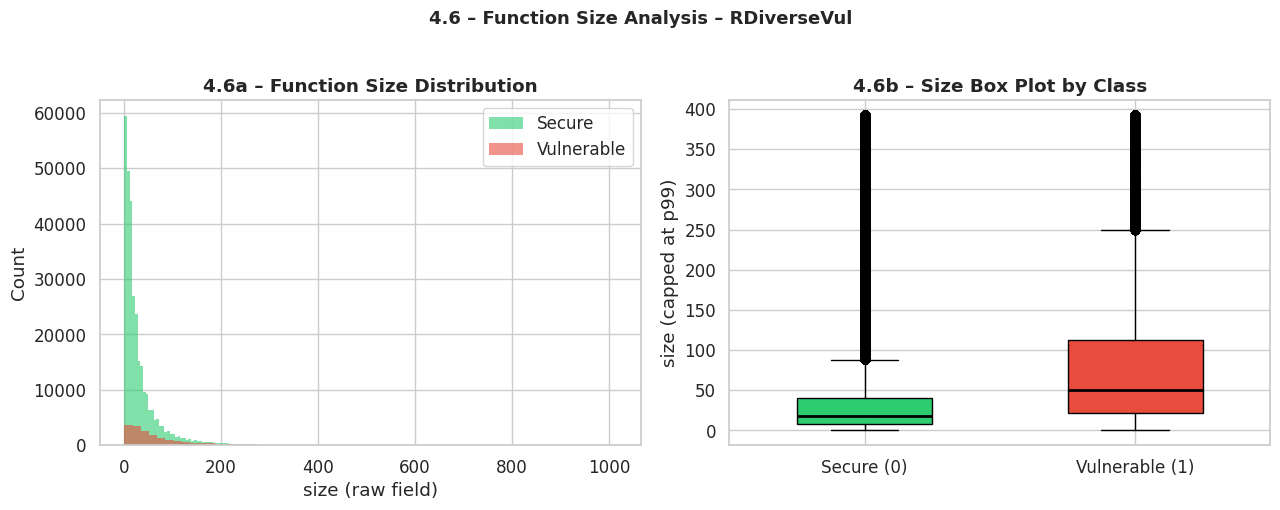

    Saved → eda_outputs/function_size.png
    Correlation (size vs n_tokens): 0.974


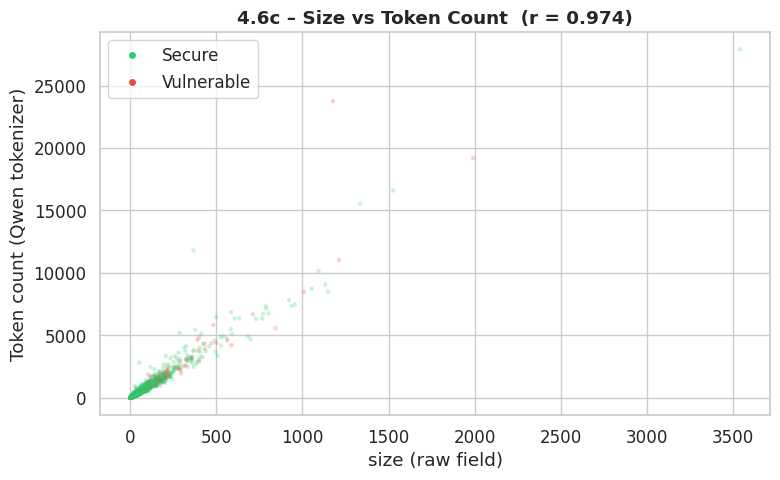

    Saved → eda_outputs/size_vs_tokens.png


In [14]:
def analyze_function_size(df, size_col=SIZE_COL, label_col=LABEL_COL, tok_df=None):
    print("\n[4.6] Function Size Analysis")
    if size_col not in df.columns:
        print(f"    WARNING: '{size_col}' not found. Skipping.")
        return

    df = df.copy()
    df[size_col] = pd.to_numeric(df[size_col], errors="coerce")
    df = df.dropna(subset=[size_col])
    print(f"    Valid size entries: {len(df):,}")

    for label, name in [(0, "Secure"), (1, "Vulnerable")]:
        s = df[df[label_col] == label][size_col]
        print(f"    {name:12s} — mean={s.mean():.1f}  median={s.median():.1f}  "
              f"p95={s.quantile(0.95):.1f}  max={s.max():.0f}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    ax = axes[0]
    for label, name, color in [(0, "Secure", PALETTE["secure"]),
                                (1, "Vulnerable", PALETTE["vulnerable"])]:
        data = df[df[label_col] == label][size_col]
        cap  = data.quantile(0.99)
        sns.histplot(data[data <= cap], bins=60, ax=ax, color=color,
                     label=name, alpha=0.6, edgecolor="none")
    ax.set_title("4.6a – Function Size Distribution", fontweight="bold")
    ax.set_xlabel(f"{size_col} (raw field)")
    ax.set_ylabel("Count")
    ax.legend()

    ax2 = axes[1]
    data_box = [df[df[label_col] == 0][size_col].clip(upper=df[size_col].quantile(0.99)),
                df[df[label_col] == 1][size_col].clip(upper=df[size_col].quantile(0.99))]
    bp = ax2.boxplot(data_box, patch_artist=True, widths=0.5,
                     medianprops=dict(color="black", lw=2))
    bp["boxes"][0].set_facecolor(PALETTE["secure"])
    bp["boxes"][1].set_facecolor(PALETTE["vulnerable"])
    ax2.set_xticklabels(["Secure (0)", "Vulnerable (1)"])
    ax2.set_title("4.6b – Size Box Plot by Class", fontweight="bold")
    ax2.set_ylabel(f"{size_col} (capped at p99)")

    plt.suptitle("4.6 – Function Size Analysis – RDiverseVul",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    _save("function_size.png")

    # ── Correlation: size vs token count ──────────────────────────────────────
    if tok_df is not None and "n_tokens" in tok_df.columns:
        # Pull size values by positional index from the original df
        # tok_df.index contains the original row indices from df
        valid_idx = tok_df.index.intersection(df.index)
        if len(valid_idx) > 100:
            merged = tok_df.loc[valid_idx, ["n_tokens", label_col]].copy()
            merged["_size"] = df.loc[valid_idx, size_col].values
            merged = merged.dropna(subset=["_size", "n_tokens"])

            corr = merged[["_size", "n_tokens"]].corr().iloc[0, 1]
            print(f"    Correlation (size vs n_tokens): {corr:.3f}")

            fig3, ax3 = plt.subplots(figsize=(8, 5))
            sample_m = merged.sample(min(5000, len(merged)), random_state=42)
            colors_c = [PALETTE["vulnerable"] if l == 1 else PALETTE["secure"]
                        for l in sample_m[label_col]]
            ax3.scatter(sample_m["_size"], sample_m["n_tokens"],
                        c=colors_c, alpha=0.25, s=10, linewidths=0)
            ax3.set_xlabel(f"{size_col} (raw field)")
            ax3.set_ylabel("Token count (Qwen tokenizer)")
            ax3.set_title(f"4.6c – Size vs Token Count  (r = {corr:.3f})", fontweight="bold")
            from matplotlib.lines import Line2D
            legend_els = [Line2D([0],[0], marker='o', color='w',
                                  markerfacecolor=PALETTE["secure"], label="Secure"),
                          Line2D([0],[0], marker='o', color='w',
                                  markerfacecolor=PALETTE["vulnerable"], label="Vulnerable")]
            ax3.legend(handles=legend_els)
            plt.tight_layout()
            _save("size_vs_tokens.png")
        else:
            print("    Not enough overlapping rows for size vs token scatter — skipping.")

analyze_function_size(df, tok_df=tok_df)

## 4.7 · Commit Message Exploration


[4.7] Commit Message Exploration  ⚠️  (EDA-only — never use for training)
    Top 20 commit keywords (vulnerable samples):
      com                   14,326
      off                   12,370
      signed                11,818
      org                   8,726
      kernel                5,527
      size                  5,453
      can                   5,291
      check                 5,134
      cve                   4,909
      which                 4,343
      bug                   4,294
      fixes                 4,256
      net                   4,208
      code                  4,053
      data                  3,986
      user                  3,682
      will                  3,676
      buffer                3,630
      memory                3,520
      but                   3,513


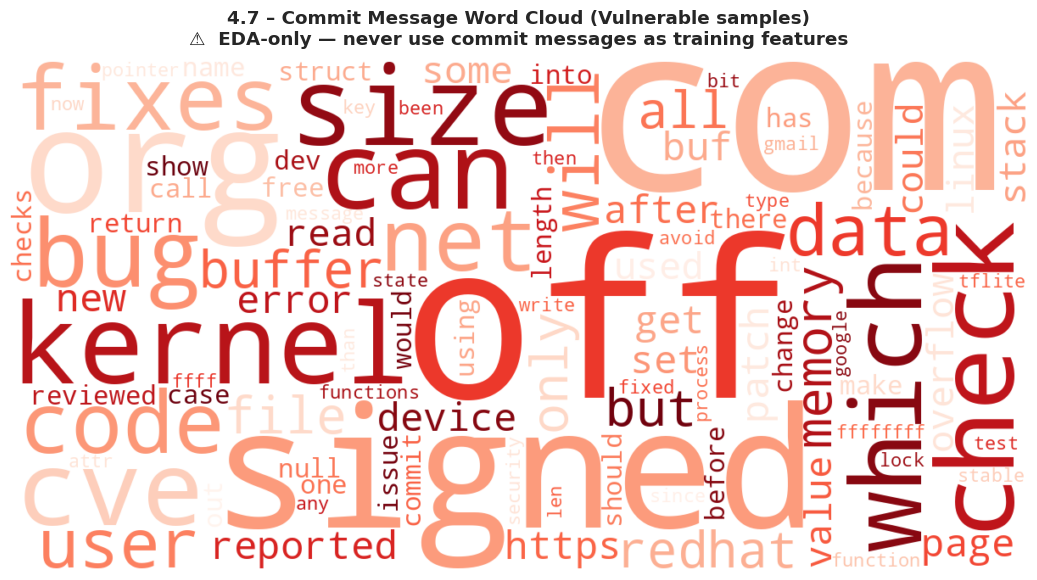

    Saved → eda_outputs/commit_wordcloud.png


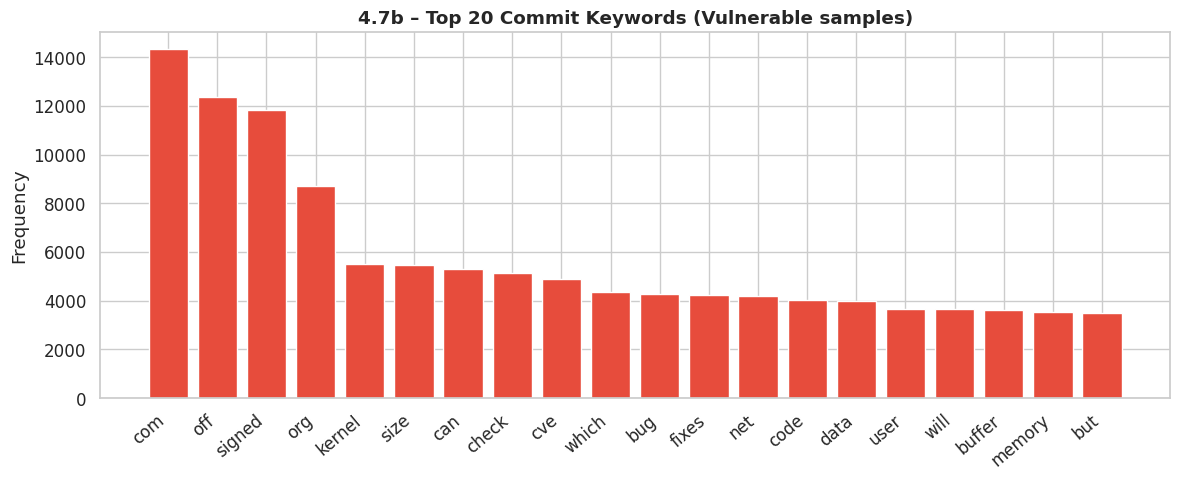

    Saved → eda_outputs/commit_keywords.png


In [15]:
def analyze_commit_messages(df, msg_col=MSG_COL, label_col=LABEL_COL):
    print("\n[4.7] Commit Message Exploration  ⚠️  (EDA-only — never use for training)")
    if msg_col not in df.columns:
        print(f"    WARNING: '{msg_col}' column not found. Skipping.")
        return

    vul_msgs = df[df[label_col] == 1][msg_col].dropna().astype(str)
    if len(vul_msgs) == 0:
        print("    No messages for vulnerable samples. Skipping.")
        return

    STOP = {"the", "a", "an", "in", "of", "to", "for", "and", "or", "is",
            "it", "be", "as", "on", "with", "this", "that", "are", "was",
            "by", "not", "at", "from", "fix", "use", "add", "when", "if",
            "also", "do", "have", "its", "was", "i", "we"}
    tokens = []
    for msg in vul_msgs:
        tokens.extend(re.findall(r"[a-z]+", msg.lower()))
    freq = Counter(t for t in tokens if t not in STOP and len(t) > 2)

    print(f"    Top 20 commit keywords (vulnerable samples):")
    for word, cnt in freq.most_common(20):
        print(f"      {word:20s}  {cnt:5,}")

    try:
        from wordcloud import WordCloud
        wc = WordCloud(width=1200, height=600,
                       background_color="white",
                       colormap="Reds",
                       max_words=100).generate_from_frequencies(freq)
        fig, ax = plt.subplots(figsize=(14, 6))
        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")
        ax.set_title("4.7 – Commit Message Word Cloud (Vulnerable samples)\n"
                     "⚠️  EDA-only — never use commit messages as training features",
                     fontweight="bold", pad=12)
        plt.tight_layout()
        _save("commit_wordcloud.png")
    except ImportError:
        print("    wordcloud not installed — skipping word-cloud plot.")

    top_words = freq.most_common(20)
    words, counts = zip(*top_words)
    fig2, ax2 = plt.subplots(figsize=(12, 5))
    ax2.bar(words, counts, color=PALETTE["vulnerable"], edgecolor="white")
    ax2.set_title("4.7b – Top 20 Commit Keywords (Vulnerable samples)", fontweight="bold")
    ax2.set_ylabel("Frequency")
    plt.xticks(rotation=40, ha="right")
    plt.tight_layout()
    _save("commit_keywords.png")

analyze_commit_messages(df)

## 4.8 · Split Strategy Analysis


[4.8] Split Strategy Analysis
    Project-disjoint — train: 640  val: 80  test: 80
    Commit-disjoint  — train: 6123  val: 765  test: 765

    Strategy               Split           N   Vuln %
    --------------------------------------------------
    Random                 Train     264,394     5.7%
    Random                 Val        33,049     5.7%
    Random                 Test       33,049     5.9%

    Project-disjoint       Train     209,364     5.6%
    Project-disjoint       Val        91,916     5.2%
    Project-disjoint       Test       29,212     8.6%

    Commit-disjoint        Train     270,516     5.8%
    Commit-disjoint        Val        30,461     5.4%
    Commit-disjoint        Test       29,515     5.7%



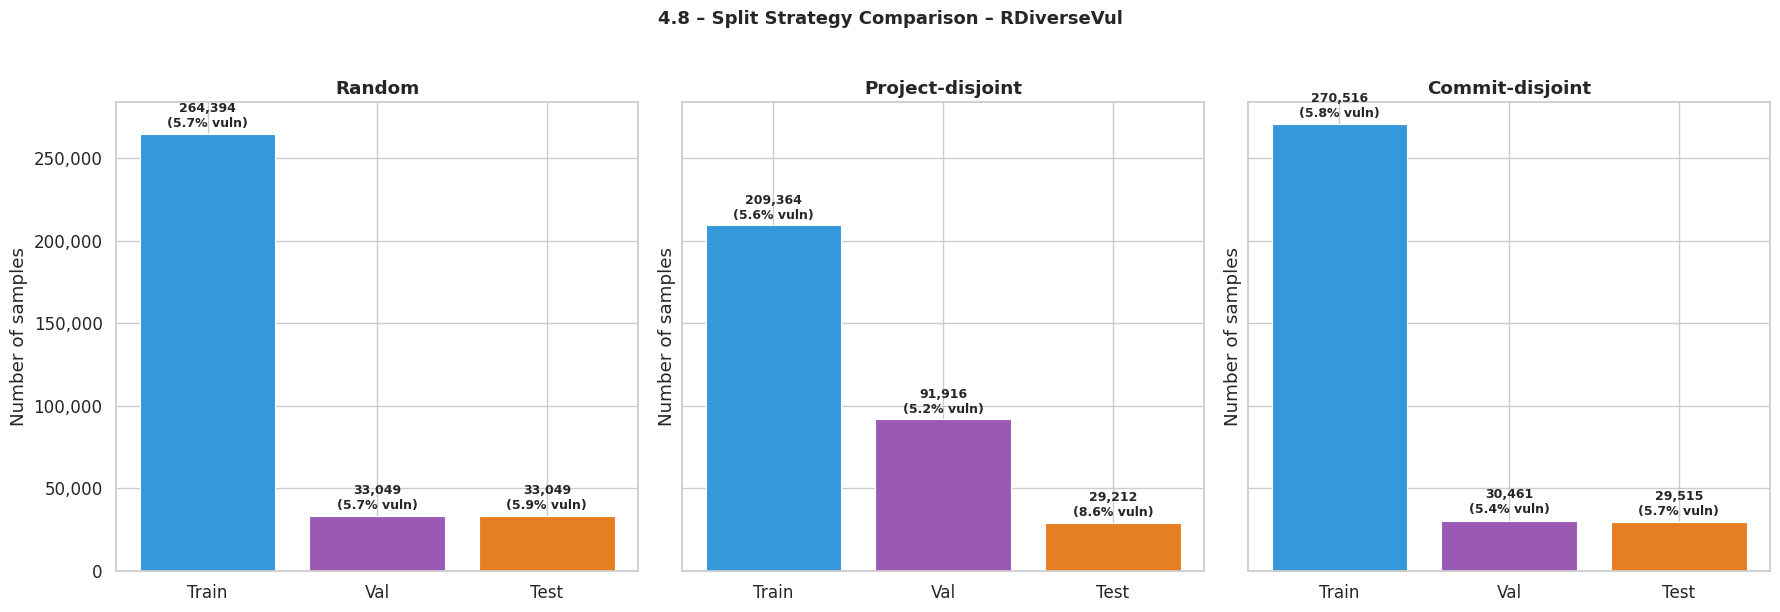

    Saved → eda_outputs/split_strategy.png


In [16]:
def analyze_split_strategies(df, project_col=PROJECT_COL, commit_col=COMMIT_COL,
                              label_col=LABEL_COL, test_frac=0.10):
    print("\n[4.8] Split Strategy Analysis")
    rng     = np.random.default_rng(42)
    results = {}

    idx   = rng.permutation(len(df))
    n_val = int(len(df) * test_frac)
    test_idx  = idx[:n_val]
    val_idx   = idx[n_val:2 * n_val]
    train_idx = idx[2 * n_val:]

    def _summary(indices, name):
        sub = df.iloc[indices]
        vr  = sub[label_col].mean() * 100
        return {"name": name, "n": len(sub), "vuln_rate": vr}

    results["Random"] = {
        "Train": _summary(train_idx, "Train"),
        "Val":   _summary(val_idx,   "Val"),
        "Test":  _summary(test_idx,  "Test"),
    }

    if project_col in df.columns:
        projects = df[project_col].unique().tolist()
        rng.shuffle(projects)
        n_p     = len(projects)
        n_ptest = max(1, int(n_p * test_frac))
        test_projs  = set(projects[:n_ptest])
        val_projs   = set(projects[n_ptest:2 * n_ptest])
        train_projs = set(projects[2 * n_ptest:])
        results["Project-disjoint"] = {
            "Train": _summary(df.index[df[project_col].isin(train_projs)].tolist(), "Train"),
            "Val":   _summary(df.index[df[project_col].isin(val_projs)].tolist(),   "Val"),
            "Test":  _summary(df.index[df[project_col].isin(test_projs)].tolist(),  "Test"),
        }
        print(f"    Project-disjoint — train: {len(train_projs)}  val: {len(val_projs)}  test: {len(test_projs)}")
    else:
        print(f"    WARNING: '{project_col}' not found — skipping project-disjoint split.")

    if commit_col in df.columns:
        commits = df[commit_col].unique().tolist()
        rng.shuffle(commits)
        n_c     = len(commits)
        n_ctest = max(1, int(n_c * test_frac))
        test_commits  = set(commits[:n_ctest])
        val_commits   = set(commits[n_ctest:2 * n_ctest])
        train_commits = set(commits[2 * n_ctest:])
        results["Commit-disjoint"] = {
            "Train": _summary(df.index[df[commit_col].isin(train_commits)].tolist(), "Train"),
            "Val":   _summary(df.index[df[commit_col].isin(val_commits)].tolist(),   "Val"),
            "Test":  _summary(df.index[df[commit_col].isin(test_commits)].tolist(),  "Test"),
        }
        print(f"    Commit-disjoint  — train: {len(train_commits)}  val: {len(val_commits)}  test: {len(test_commits)}")
    else:
        print(f"    WARNING: '{commit_col}' not found — skipping commit-disjoint split.")

    print(f"\n    {'Strategy':<22} {'Split':<8} {'N':>8}  {'Vuln %':>7}")
    print("    " + "-" * 50)
    for strategy, splits in results.items():
        for split_name, info in splits.items():
            print(f"    {strategy:<22} {split_name:<8} {info['n']:>8,}  {info['vuln_rate']:>6.1f}%")
        print()

    strategies   = list(results.keys())
    splits_order = ["Train", "Val", "Test"]
    split_colors = ["#3498DB", "#9B59B6", "#E67E22"]

    fig, axes = plt.subplots(1, len(strategies), figsize=(6 * len(strategies), 6), sharey=True)
    if len(strategies) == 1:
        axes = [axes]

    for ax, strategy in zip(axes, strategies):
        splits = results[strategy]
        ns     = [splits[s]["n"]         for s in splits_order if s in splits]
        vrates = [splits[s]["vuln_rate"] for s in splits_order if s in splits]
        snames = [s                       for s in splits_order if s in splits]
        bars = ax.bar(snames, ns, color=split_colors[:len(snames)], edgecolor="white", linewidth=0.8)
        for bar, n, vr in zip(bars, ns, vrates):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(ns) * 0.01,
                    f"{n:,}\n({vr:.1f}% vuln)",
                    ha="center", va="bottom", fontsize=9, fontweight="bold")
        ax.set_title(f"{strategy}", fontweight="bold")
        ax.set_ylabel("Number of samples")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))

    plt.suptitle("4.8 – Split Strategy Comparison – RDiverseVul",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    _save("split_strategy.png")

analyze_split_strategies(df)

## 6 · Save summary report

In [17]:
def save_summary(df, label_col=LABEL_COL, cwe_col=CWE_COL):
    counts = df[label_col].value_counts().sort_index()
    vul_n  = int(counts.get(1, 0))
    sec_n  = int(counts.get(0, 0))
    lines = [
        "# RDiverseVul – EDA Summary (v2)\n\n",
        f"**Total samples:** {len(df):,}\n",
        f"**Vulnerable (1):** {vul_n:,} ({vul_n/len(df)*100:.1f}%)\n",
        f"**Secure (0):** {sec_n:,} ({sec_n/len(df)*100:.1f}%)\n",
        f"**Imbalance ratio:** {sec_n/max(vul_n,1):.1f}:1\n\n",
        "## Output files\n",
        "| File | Analysis |\n",
        "|------|----------|\n",
        "| `class_imbalance.png` | 4.1 Class imbalance |\n",
        "| `token_length_distribution.png` | 4.2 Token lengths |\n",
        "| `cwe_distribution.png` | 4.3 CWE top-N |\n",
        "| `cwe_by_class.png` | 4.3b CWE × class |\n",
        "| `project_distribution.png` | 4.4 Project distribution |\n",
        "| `project_stats.csv` | 4.4 Per-project CSV |\n",
        "| `duplicate_detection.png` | 4.5 Duplicate analysis |\n",
        "| `function_size.png` | 4.6 Size distribution |\n",
        "| `size_vs_tokens.png` | 4.6c Size vs token count |\n",
        "| `commit_wordcloud.png` | 4.7 Commit word cloud |\n",
        "| `commit_keywords.png` | 4.7b Commit keyword freq |\n",
        "| `split_strategy.png` | 4.8 Split strategy comparison |\n",
        "\n## Key findings & recommendations\n",
        "- Check project_stats.csv for per-project vulnerability rates.\n",
        "- Prefer **project-disjoint split** for rigorous cross-project evaluation.\n",
        "- Use **Focal Loss or class-weighted CE** given the imbalance ratio.\n",
        "- Never use commit messages as training features (leakage).\n",
        "- Remove duplicates before splitting (see duplicate_detection.png).\n",
    ]
    out = OUT_DIR / "eda_summary.md"
    out.write_text("".join(lines), encoding="utf-8")
    print(f"\n    Summary saved → {out}")

save_summary(df)
print("\n✅  EDA v2 complete. All outputs saved to ./eda_outputs/")
print(f"   Total plots: {len(list(OUT_DIR.glob('*.png')))} PNG files + 1 CSV + 1 Markdown summary")


    Summary saved → eda_outputs/eda_summary.md

✅  EDA v2 complete. All outputs saved to ./eda_outputs/
   Total plots: 11 PNG files + 1 CSV + 1 Markdown summary


## 7 ·Download all outputs as a zip

In [18]:
import shutil
from google.colab import files

zip_path = shutil.make_archive("eda_outputs", "zip", "eda_outputs")
print(f"Created: {zip_path}")
files.download(zip_path)

Created: /content/eda_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>